<h1>Feature importances</h1>

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

df_numeric = data_selector.df.select_dtypes(include=['number'])
correlation_matrix = df_numeric.corr()

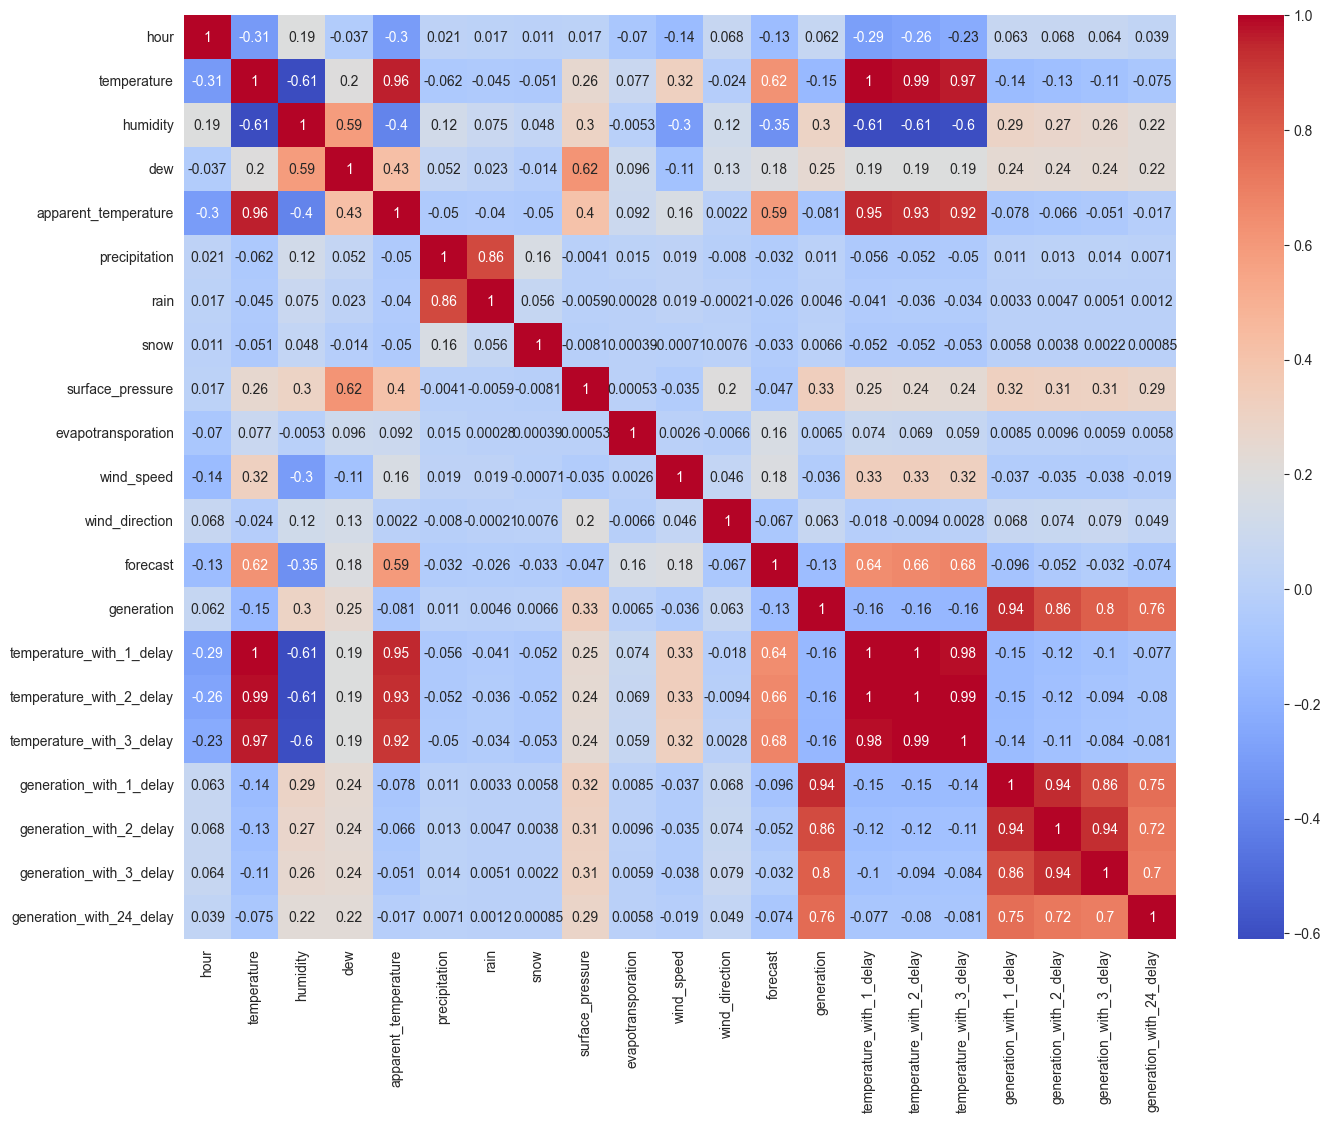

In [3]:
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

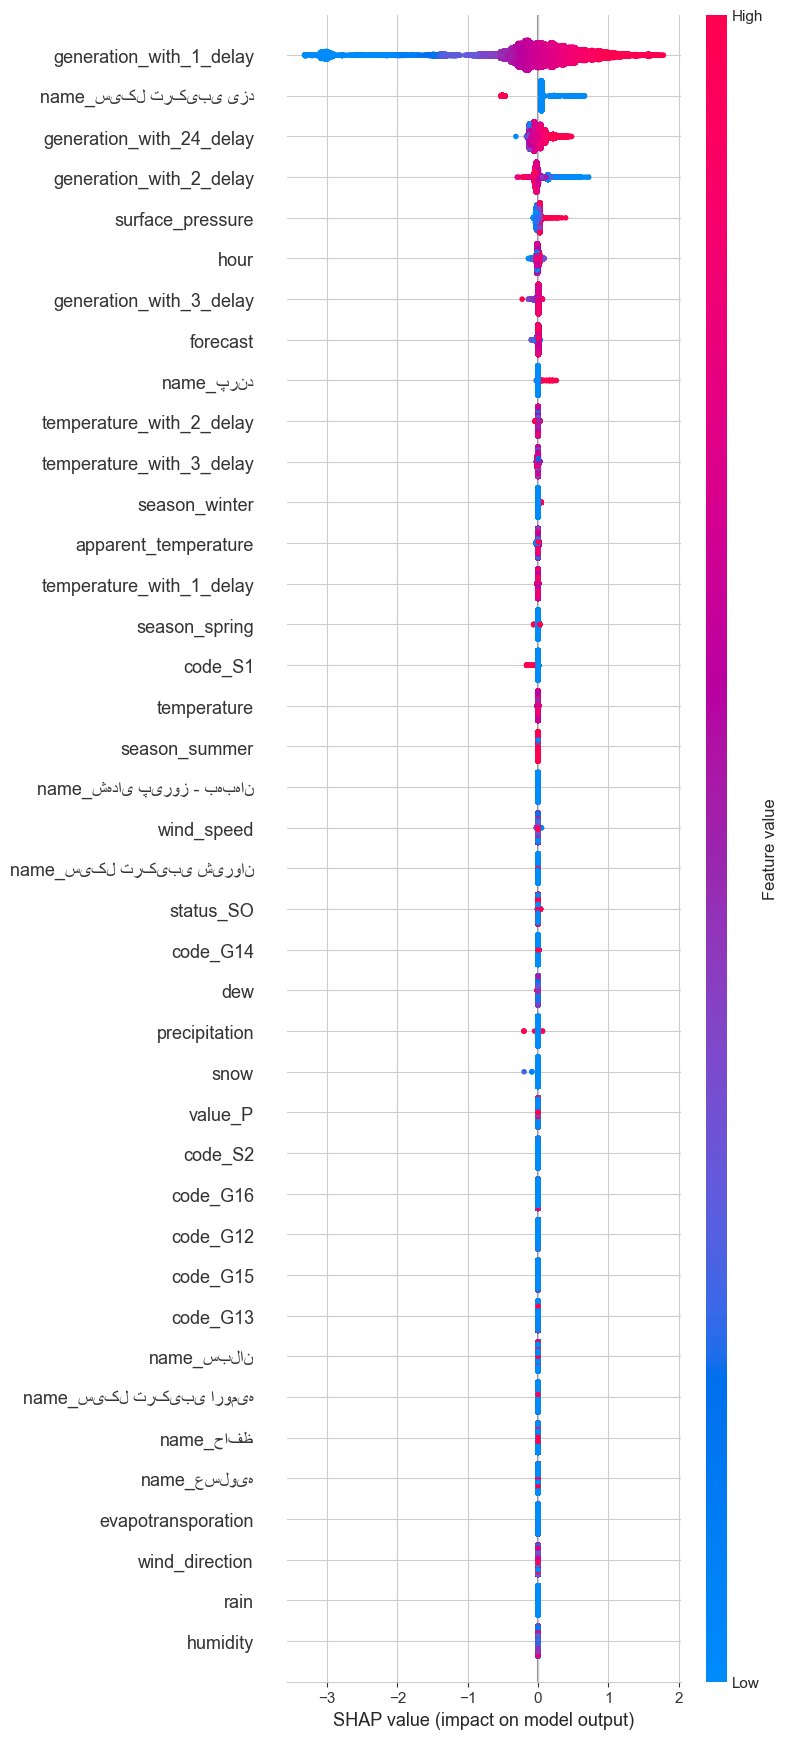

In [4]:
# Check features importance:

from models import XGBoost
import xgboost as xgb
import shap

xgb_model = XGBoost()
xgb_model.scale_and_split_data(X, y)

model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=3)
model.fit(xgb_model.X_train, xgb_model.y_train)
xgb_model.model = model

columns = list(feature_selector.df.columns)
columns.remove("generation")
X_test_df = pd.DataFrame(xgb_model.X_test, columns=columns)

explainer = shap.Explainer(model)

shap_values = explainer(X_test_df)

shap.summary_plot(shap_values, X_test_df, max_display=60)
